In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv('/Users/Deep/Downloads/StrokePrediction/StrokePrediction_MachineLearning_LLM/healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
df_copy = df.copy()

In [3]:
df_copy.drop('id', axis=1, inplace=True)

In [4]:
df_copy['stroke'].unique()

array([1, 0])

In [5]:
df_copy.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
df_copy.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
df_copy['stroke'].where(df_copy['stroke']==1).value_counts() 

stroke
1.0    249
Name: count, dtype: int64

In [8]:

bmi_null_data = df_copy[df_copy['bmi'].isnull()]
bmi_null_data['stroke'].where(bmi_null_data['stroke'] == 1).value_counts()
#bmi_null_data.to_csv('bmi_null_data.csv', index=False)



stroke
1.0    40
Name: count, dtype: int64

#Imputing the missing BMI values since BMI is missing for 40 people who got Stroke out of 249 total.. 

In [9]:
# Used grouped median imputation to fill missing BMI
#age bins and labels for filling missing BMI values
bins = [0, 25, 45, 65, 85, 100]
labels = ['young', 'early_adult', 'middle_aged', 'senior', 'elderly']

df_copy['age_group'] = pd.cut(df_copy['age'], bins=bins, labels=labels)

# Fill missing BMI with median of each age group
df_copy['bmi'] = df_copy.groupby('age_group', observed=True)['bmi'].transform(
    lambda x: x.fillna(x.median())
)

# Drop helper column
df_copy.drop('age_group', axis=1, inplace=True)

# Verify
print(df_copy['bmi'].isnull().sum())  

0


In [10]:
df_copy.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.870724,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.717508,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.300000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
df_copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 594.7 KB


In [12]:
feature_columns = df_copy.columns
print(feature_columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [13]:
#gender ever_married, work_type, residence_type,smoking_status are categorical 

print(df_copy['gender'].unique())
print(df_copy['ever_married'].unique())
print(df_copy['work_type'].unique())
print(df_copy['Residence_type'].unique())
print(df_copy['smoking_status'].unique())

<ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
<ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
<ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str
<ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


In [14]:
# #label encoding for categorical variables 
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
# for col in categorical_cols:
#     df_copy[col] = le.fit_transform(df_copy[col])               

# df_copy.head()
# df_copy.to_csv('stroke_prediction_preprocessed.csv', index=False)   

In [15]:
df_copy.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [16]:
df_copy['ever_married'] = df_copy['ever_married'].map({'No': 0, 'Yes': 1}).astype(int)

In [17]:
cat_cols = ['gender','work_type','Residence_type','smoking_status']

def preprocess_data(df):
    df_processed = df.copy()
    # One-hot encode categorical variables
    df_processed = pd.get_dummies(df_processed, columns=cat_cols, drop_first=True)
    
    bool_cols = df_processed.select_dtypes(include='bool').columns
    df_processed[bool_cols] = df_processed[bool_cols].astype(int)
    return df_processed

df_preprocessed = preprocess_data(df_copy)
df_preprocessed.head()



,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,1,228.69,36.6,1,1,0,0,1,0,0,1,1,0,0
1,61.0,0,0,1,202.21,30.3,1,0,0,0,0,1,0,0,0,1,0
2,80.0,0,1,1,105.92,32.5,1,1,0,0,1,0,0,0,0,1,0
3,49.0,0,0,1,171.23,34.4,1,0,0,0,1,0,0,1,0,0,1
4,79.0,1,0,1,174.12,24.0,1,0,0,0,0,1,0,0,0,1,0


In [18]:
num_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_cols)

['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


/var/folders/jd/746wbsm133x23cvkw2qlxzmh0000gp/T/ipykernel_16344/99920668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df_preprocessed, palette='Set2')


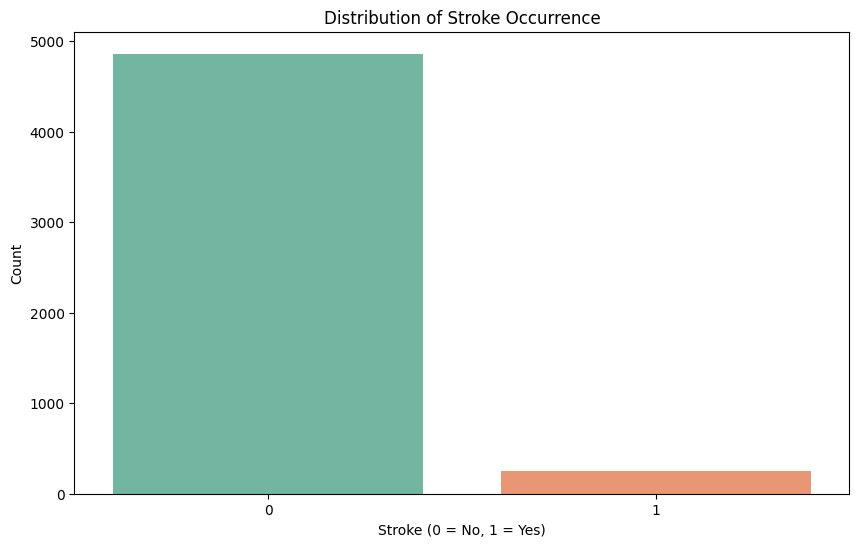

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(10,6))
sns.countplot(x='stroke', data=df_preprocessed, palette='Set2')
plt.title('Distribution of Stroke Occurrence')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

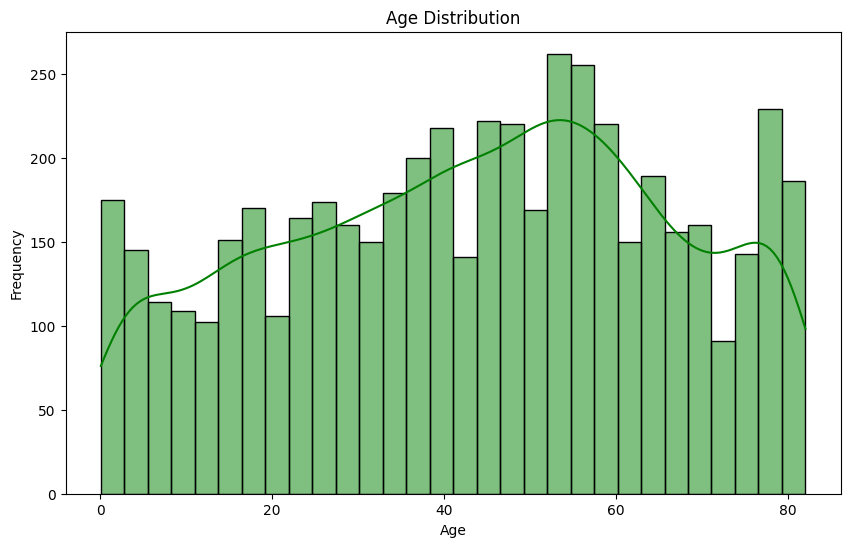

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df_preprocessed['age'], bins=30, kde=True,color='green')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

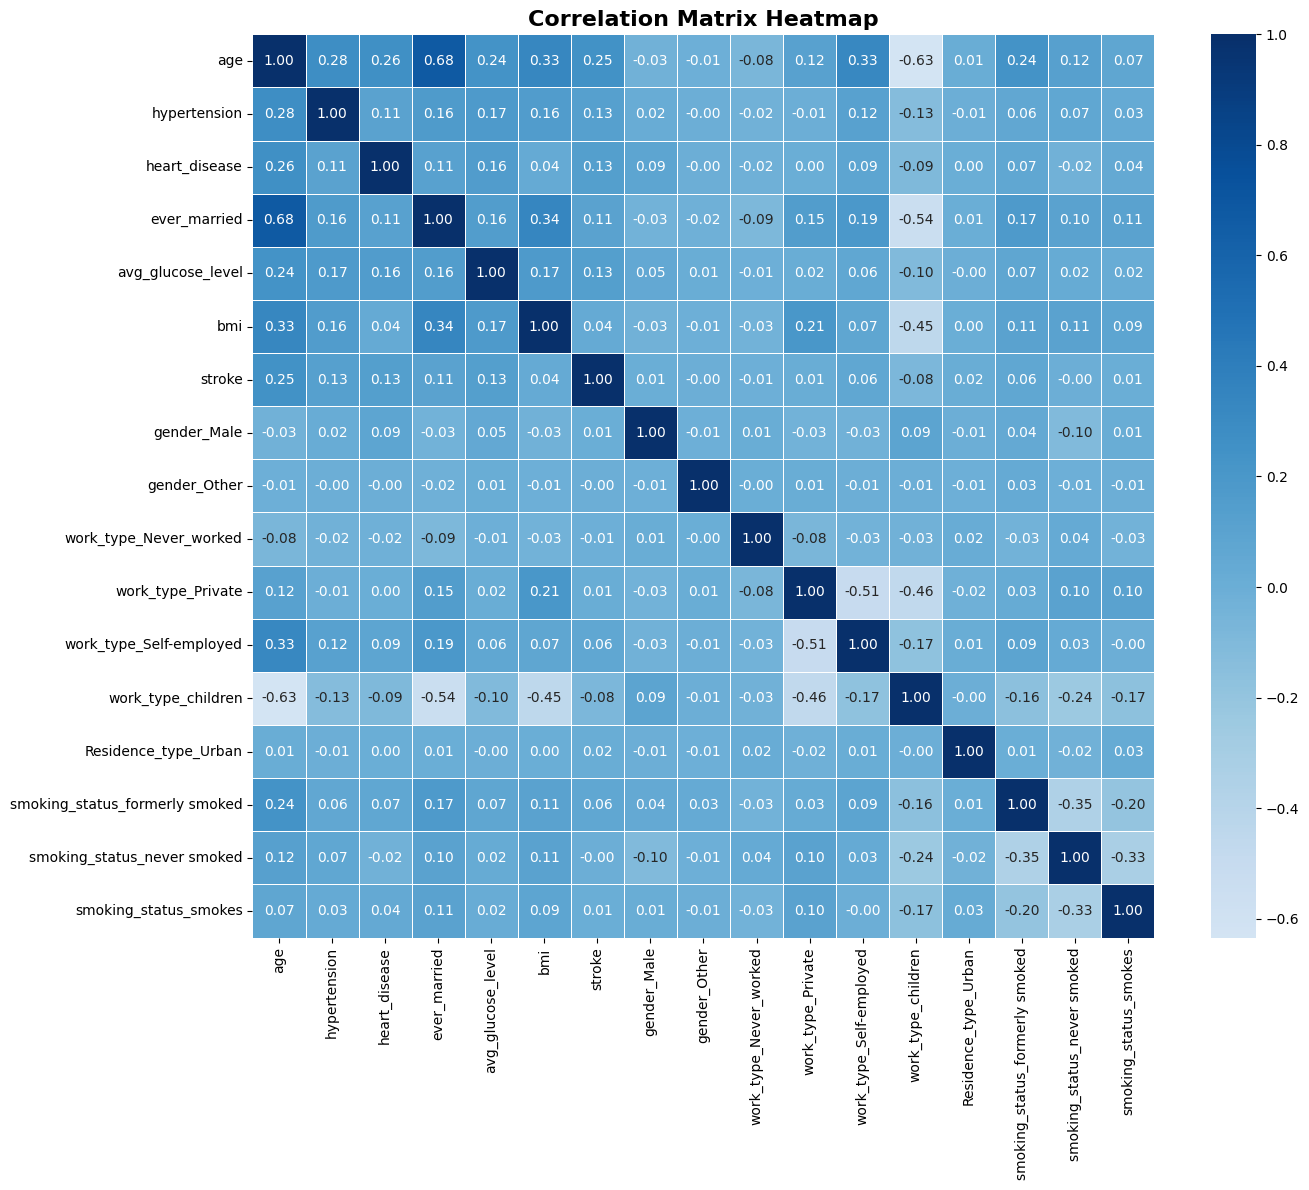

In [21]:
num_df = df_preprocessed.select_dtypes(include=['int64', 'float64'])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(num_df.corr(), 
            cmap='Blues',      # Red-Yellow-Green is more intuitive
            center=0,
            annot=True,          # Show actual numbers
            fmt='.2f',
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')

# # Highlight stroke row and column
# ax.add_patch(plt.Rectangle(
#     (0, df.columns.get_loc('stroke')), 
#     len(df.columns), 1, 
#     fill=False, edgecolor='blue', lw=3
# ))

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)

In [22]:

feature_cols = [c for c in df_preprocessed.columns if c != 'stroke']

X = df_preprocessed[feature_cols].values
y = df_preprocessed['stroke'].values

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

X = df_preprocessed.drop('stroke', axis=1)
y = df_preprocessed['stroke']

from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

# Split FIRST before any resampling — never resample test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Original train set (for comparison)
X_train_orig, y_train_orig = X_train.copy(), y_train.copy()

#  Oversample (SMOTE on train only)
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# Undersample (train only)
undersample = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)

# Check sizes
print("Original:    ", X_train_orig.shape,pd.Series(y_train_orig).value_counts().to_dict())
print("Oversampled: ", X_train_over.shape, pd.Series(y_train_over).value_counts().to_dict())
print("Undersampled:", X_train_under.shape, pd.Series(y_train_under).value_counts().to_dict())

Original:     (4088, 16) {0: 3889, 1: 199}
Oversampled:  (7778, 16) {0: 3889, 1: 3889}
Undersampled: (398, 16) {0: 199, 1: 199}


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ,balanced_accuracy_score,precision_score ,roc_auc_score,f1_score

In [31]:

#Scaling the data using StandardScaler
# Original
from sklearn.preprocessing import StandardScaler

#scaling only time-related features 
cols_to_scale = ['age', 'avg_glucose_level', 'bmi']

scaler_orig = StandardScaler()
X_train_orig_scaled = pd.DataFrame(scaler_orig.fit_transform(X_train_orig[cols_to_scale]), columns=cols_to_scale)
X_test_orig_scaled  = pd.DataFrame(scaler_orig.transform(X_test[cols_to_scale]), columns=cols_to_scale)

# Oversampled
scaler_over = StandardScaler()
X_train_over_scaled = pd.DataFrame(scaler_over.fit_transform(X_train_over[cols_to_scale]), columns=cols_to_scale)
X_test_over_scaled  = pd.DataFrame(scaler_over.transform(X_test[cols_to_scale]), columns=cols_to_scale)

# Undersampled
scaler_under = StandardScaler()
X_train_under_scaled = pd.DataFrame(scaler_under.fit_transform(X_train_under[cols_to_scale]), columns=cols_to_scale)
X_test_under_scaled  = pd.DataFrame(scaler_under.transform(X_test[cols_to_scale]), columns=cols_to_scale)




In [32]:
# creating dataversions to easily use for modeling different versions of data for modelingdata_versions_scaled = {
data_versions_scaled = {
    'Scaled_original' : (X_train_orig_scaled, y_train_orig, X_test_orig_scaled),
    'Oversampled' : (X_train_over_scaled,   y_train_over,X_test_over_scaled),
    'Undersampled' : (X_train_under_scaled, y_train_under, X_test_under_scaled)
   
}

data_versions_tree = {
    'Original' :(X_train_orig, y_train_orig,X_test),    
    'Oversampled' : (X_train_over,  y_train_over,X_test),
    'Undersampled' : (X_train_under, y_train_under,X_test)
}

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier


scaled_models ={
   'logistic_regression': LogisticRegression(random_state=42),
   'knn' : KNeighborsClassifier(n_neighbors=13),
   'svm':SVC(kernel='rbf',random_state=42, probability=True),
   'lda': LinearDiscriminantAnalysis(),
   'gaussian_nb': GaussianNB(),
   'mlp': MLPClassifier(hidden_layer_sizes=(100,),random_state=42, max_iter=500)
}

tree_models ={
    'dt_unpruned' : DecisionTreeClassifier(random_state=42),
    'dt_pruned': DecisionTreeClassifier(max_depth=5, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'xgboost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42,verbosity=0),
    'gradient_boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'adaboost': AdaBoostClassifier(n_estimators=100, random_state=42)
}


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model', version_name=''):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*55}")
    print(f"  {model_name.upper()}  |  Version: {version_name}")
    print(f"{'='*55}")

    # ── Classification report only (no confusion matrix) ─────────────────────
    print(classification_report(y_test, y_pred,
                                 target_names=['Office (0)', 'WFH (1)'],
                                 zero_division=0))

    accuracy    = accuracy_score(y_test, y_pred)
    precision   = precision_score(y_test, y_pred, zero_division=0)
    specificity = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1          = f1_score(y_test, y_pred, zero_division=0)

    print(f"  Accuracy               : {accuracy*100:.2f}%")
    print(f"  Precision              : {precision*100:.2f}%")
    print(f"  Specificity (Recall[0]): {specificity*100:.2f}%")
    print(f"  Sensitivity (Recall[1]): {sensitivity*100:.2f}%")
    print(f"  F1-Score               : {f1*100:.2f}%")
    print(f"{'='*55}")

    return {
        'Model'                   : model_name,
        'Version'                 : version_name,
        'Accuracy'                : round(accuracy * 100, 2),
        'Precision'               : round(precision * 100, 2),
        'Specificity (Recall[0])' : round(specificity * 100, 2),
        'Sensitivity (Recall[1])' : round(sensitivity * 100, 2),
        'F1'                      : round(f1 * 100, 2)
    }

In [35]:
all_results = []


#  RUN ALL THE MODELS 
def run_all_models(model_dict, version_dict, y_test):
    for version_name, (X_train_v, y_train_v, X_test_v) in version_dict.items():
        for model_name, model in model_dict.items():
            result = evaluate_model(
                model      = model,
                X_train    = X_train_v,
                y_train    = y_train_v,
                X_test     = X_test_v,
                y_test     = y_test,
                model_name = model_name,
                version_name = version_name
            )
            all_results.append(result)

# Run scaled models 
print("\n" + "█"*55)
print("   SCALED MODELS")
print("█"*55)
run_all_models(scaled_models, data_versions_scaled, y_test)

# Run tree models 
print("\n" + "█"*55)
print("   TREE MODELS")
print("█"*55)
run_all_models(tree_models, data_versions_tree, y_test)

# ── Final table ────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
print(results_df)



███████████████████████████████████████████████████████
   SCALED MODELS
███████████████████████████████████████████████████████

  LOGISTIC_REGRESSION  |  Version: Scaled_original
              precision    recall  f1-score   support

  Office (0)       0.95      1.00      0.97       972
     WFH (1)       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

  Accuracy               : 95.11%
  Precision              : 0.00%
  Specificity (Recall[0]): 100.00%
  Sensitivity (Recall[1]): 0.00%
  F1-Score               : 0.00%

  KNN  |  Version: Scaled_original
              precision    recall  f1-score   support

  Office (0)       0.95      1.00      0.97       972
     WFH (1)       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg   

In [36]:
# ── Rename for clean display ──────────────────────────────────────────────────
results_df_display = results_df.rename(columns={
    'Specificity (Recall[0])' : 'Complete Physical Attendance (Recall[0])',
    'Sensitivity (Recall[1])' : 'Work/Study from Home (Recall[1])'
})

# ── Final pivot table ─────────────────────────────────────────────────────────
final_pivot = results_df_display.pivot_table(
    index   = ['Model', 'Version'],
    values  = [
        'Accuracy',
        'Precision',
        'Complete Physical Attendance (Recall[0])',
        'Work/Study from Home (Recall[1])',
        'F1'
    ]
).round(2)

# ── Reorder columns ───────────────────────────────────────────────────────────
final_pivot = final_pivot[[
    'Accuracy',
    'Precision',
    'Complete Physical Attendance (Recall[0])',
    'Work/Study from Home (Recall[1])',
    'F1'
]]

print(final_pivot.to_string())
final_pivot.to_csv('model_comparison_results.csv')

                                     Accuracy  Precision  Complete Physical Attendance (Recall[0])  Work/Study from Home (Recall[1])     F1
Model               Version                                                                                                                
adaboost            Original            95.11       0.00                                    100.00                               0.0   0.00
                    Oversampled         83.76      15.88                                     85.29                              54.0  24.55
                    Undersampled        65.36      10.21                                     64.71                              78.0  18.06
dt_pruned           Original            94.81       0.00                                     99.69                               0.0   0.00
                    Oversampled         81.31      12.30                                     83.13                              46.0  19.41
                    

In [38]:
print(scaled_models.keys())
print(tree_models.keys())

dict_keys(['logistic_regression', 'knn', 'svm', 'lda', 'gaussian_nb', 'mlp'])
dict_keys(['dt_unpruned', 'dt_pruned', 'random_forest', 'xgboost', 'gradient_boosting', 'adaboost'])


************************v\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
**********************************************************************************************

In [ ]:
import pickle

with open('models_pipeline.pkl', 'wb') as f:
    pickle.dump({
        'scaled_models'         : scaled_models,
        'tree_models'           : tree_models,
        'data_versions_scaled'  : data_versions_scaled,
        'data_versions_tree'    : data_versions_tree,
        'X_test_scaled'         : X_test_under_scaled,
        'X_test'                : X_test,
        'y_test'                : y_test,
    }, f)

print("Saved to models_pipeline.pkl")

Saved to models_pipeline.pkl


In [ ]:
with open('models_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

scaled_models          = pipeline['scaled_models']
tree_models            = pipeline['tree_models']
data_versions_scaled   = pipeline['data_versions_scaled']
data_versions_tree     = pipeline['data_versions_tree']
X_test_scaled          = pipeline['X_test_under_scaled']
X_test                 = pipeline['X_test']
y_test                 = pipeline['y_test']

In [ ]:
import pandas as pd

def plot_feature_importance_all(scaled_models, tree_models,
                                 data_versions_scaled, data_versions_tree,
                                 X_test_scaled, X_test):

    model_colors = {
        'Logistic Regression' : 'royalblue',
        'SVM'                 : 'darkorange',
        'KNN'                 : 'green',
        'Random Forest'       : 'crimson',
        'Decision Tree'       : 'purple',
        'GBM'                 : 'brown',
    }

    def _plot(name, model, X_tr, y_tr, X_te, d_name):
        model.fit(X_tr, y_tr)

        feature_names = ["age", "hypertension", "heart_disease", "ever_married", "avg_glucose_level", "bmi", "gender_Male", "gender_Other", "work_type_Never_worked", "work_type_Private", "work_type_Self-employed", "work_type_children", "Residence_type_Urban", "smoking_status_formerly smoked", "smoking_status_never smoked", "smoking_status_smokes"]

        # ── KNN: no importance ──────────────────────────────
        if not hasattr(model, 'feature_importances_') \
           and not hasattr(model, 'coef_'):
            print(f"⚠️  {name} [{d_name}] — feature importance not available")
            return

        if hasattr(model, 'feature_importances_'):      # RF, DT, GBM
            importances = model.feature_importances_
            xlabel      = 'Gini Importance'
        else:                                            # LR, SVM
            importances = np.abs(model.coef_[0])
            xlabel      = 'Absolute Coefficient'

        feat_df = (pd.DataFrame({'Feature': feature_names,
                                  'Importance': importances})
                     .sort_values('Importance', ascending=True)
                     .tail(12))                          # top 12 features

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(feat_df['Feature'], feat_df['Importance'],
                color=model_colors.get(name, 'gray'), edgecolor='white')
        ax.set_title(f'Feature Importance — {name}  [{d_name}]',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel(xlabel)
        plt.tight_layout()
        fname = f'feat_imp_{name.replace(" ","_")}_{d_name}.png'
        plt.savefig(fname, dpi=300)
        plt.show()
        print(f"✅ Saved: {fname}")

    for name, model in scaled_models.items():
        for d_name, (X_tr, y_tr) in data_versions_scaled.items():
            _plot(name, model, X_tr, y_tr, X_test_under_scaled, d_name)

    for name, model in tree_models.items():
        for d_name, (X_tr, y_tr) in data_versions_tree.items():
            _plot(name, model, X_tr, y_tr, X_test, d_name)

# plot_feature_importance_all(scaled_models, tree_models,
#                              data_versions_scaled, data_versions_tree,
#                              X_test_under_scaled, X_test)

ValueError: too many values to unpack (expected 2, got 3)